In [1]:
!pip install torchinfo

In [2]:
import torch
import torchvision
from torch import nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
from torchinfo import summary

import warnings
warnings.filterwarnings("ignore")

In [3]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(device)

cuda


In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
train_data = datasets.GTSRB(
    root="data",
    split="train",
    download=True,
    transform=train_transform
)

test_data = datasets.GTSRB(
    root="data",
    split="test",
    download=True,
    transform=test_transform
)

100%|██████████| 187M/187M [00:17<00:00, 10.7MB/s]
100%|██████████| 89.0M/89.0M [00:05<00:00, 17.5MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 210kB/s]


In [6]:
class_names = [
    "Speed limit 20", "Speed limit 30", "Speed limit 50", "Speed limit 60",
    "Speed limit 70", "Speed limit 80", "End speed limit 80", "Speed limit 100",
    "Speed limit 120", "No passing", "No passing >3.5t", "Right-of-way",
    "Priority road", "Yield", "Stop", "No vehicles", "No vehicles >3.5t",
    "No entry", "General caution", "Dangerous curve left", "Dangerous curve right",
    "Double curve", "Bumpy road", "Slippery road", "Road narrows right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing",
    "Bicycles crossing", "Beware ice/snow", "Wild animals crossing",
    "End restrictions", "Turn right ahead", "Turn left ahead", "Ahead only",
    "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End no passing", "End no passing >3.5t"
]

In [7]:
len(class_names)

43

In [8]:
BATCH_SIZE=32
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

first shape: torch.Size([3, 224, 224])
permuted: torch.Size([224, 224, 3])


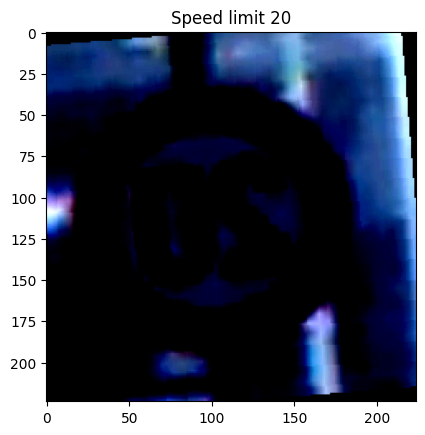

In [9]:
image, label = train_dataloader.dataset[74]
print("first shape:",image.shape)
plt.imshow(image.permute(1,2,0))
print("permuted:", image.permute(1,2,0).shape)
plt.title(class_names[label])
plt.show()

In [10]:
image = torch.tensor(data=torch.randn([3,224,224]))
print("first:",image.shape)

layer = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=16, stride=16, padding=1)
image_out_of_layer = layer(image.unsqueeze(0))
print("second:",image_out_of_layer.shape)

flatten = nn.Flatten(start_dim=2, end_dim=3)
flattened = flatten(image_out_of_layer)
print("third:", flattened.shape)

first: torch.Size([3, 224, 224])
second: torch.Size([1, 768, 14, 14])
third: torch.Size([1, 768, 196])


In [11]:
class PatchEmbedding(nn.Module):
    def __init__(self, input_size=3, patch_size=16, emdeding_dim=768):
        super().__init__()

        # image -> to patches
        self.patcher = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=16, stride=16, padding=0)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)   # after conv layer,before flatten -> 1,768,14,14

    def forward(self,x):
        x = self.patcher(x)
        x = self.flatten(x)

        return x.permute(0,2,1)      # on paper Xp -> N x (P^2*C) so finally [batch_size, N, P^2*C] -> [1, 196, 768]

In [12]:
patcher = PatchEmbedding()
print("image:",image.unsqueeze(0).shape)
patchified_image = patcher(image.unsqueeze(0))
print("patchified image:", patchified_image.shape)

image: torch.Size([1, 3, 224, 224])
patchified image: torch.Size([1, 196, 768])


In [13]:
class_token = nn.Parameter(
    data = torch.randn(1,1,768),
    requires_grad = True
)

In [14]:
PatchifiedImageWithClassToken = torch.cat(
    tensors = (class_token,patchified_image),
    dim=1     # concat on dim 1
)

PatchifiedImageWithClassToken, PatchifiedImageWithClassToken.shape        # learnable class token eklenmiş hali (ilk rowda)

(tensor([[[-0.4560, -1.2763, -0.1028,  ..., -0.7663,  0.2071,  0.6896],
          [ 0.0587,  0.6371, -1.8596,  ..., -0.1956, -1.0577, -1.1848],
          [ 0.8044,  0.5367,  0.1461,  ..., -0.2246, -1.0671,  0.8152],
          ...,
          [ 0.7267, -0.1025,  0.0027,  ...,  0.5334, -0.3626,  0.5982],
          [ 0.4778,  0.2016, -0.5122,  ...,  0.3547, -0.1659,  0.1507],
          [ 0.4218,  0.4821, -0.5172,  ..., -0.6309,  0.7155,  0.2378]]],
        grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [15]:
position_embedder = nn.Parameter(
    data = torch.randn(1, 196 + 1, 768),
    requires_grad = True
)

In [16]:
PatchClassPositionImage = position_embedder + PatchifiedImageWithClassToken

PatchClassPositionImage, PatchClassPositionImage.shape

(tensor([[[ 1.8851e+00, -1.8028e+00, -9.5560e-01,  ...,  2.6419e-01,
            1.1698e+00,  1.1667e+00],
          [ 1.7164e+00,  8.2694e-01, -2.0675e+00,  ...,  4.0362e-02,
            1.5332e+00, -8.2043e-01],
          [-3.5777e-02,  2.1756e-04,  1.3379e+00,  ..., -8.6416e-01,
           -1.3985e+00,  5.0265e-01],
          ...,
          [ 4.6577e-01, -1.8254e-01, -1.1019e+00,  ...,  1.3889e+00,
            7.1870e-01,  6.0676e-01],
          [-2.6074e-01,  8.6876e-01, -2.1844e-01,  ...,  6.4441e-01,
           -5.8428e-01,  8.3467e-01],
          [-1.1962e+00,  1.2293e+00, -2.4022e+00,  ..., -1.3623e+00,
            7.3507e-01,  6.9643e-01]]], grad_fn=<AddBackward0>),
 torch.Size([1, 197, 768]))

In [17]:
class MSA(nn.Module):
    def __init__(self, embedding_dim=768, num_heads=12, dropout=0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)

        self.mha_block = nn.MultiheadAttention(
            embed_dim = 768,
            num_heads = 12,
            dropout = 0,
            batch_first = True)   # -> batch dim first on the shape

    def forward(self,x):
            x = self.layer_norm(x)
            output, weights = self.mha_block(
                query=x,
                key=x,
                value=x,
                need_weights = False)

            return output

In [18]:
msa_block = MSA()

AfterMSA = msa_block(PatchClassPositionImage)
AfterMSA, AfterMSA.shape

(tensor([[[ 0.0035, -0.0329, -0.0046,  ...,  0.0359, -0.0016,  0.0366],
          [-0.0068, -0.0595, -0.0071,  ..., -0.0124,  0.0102, -0.0071],
          [-0.0130, -0.0205,  0.0164,  ..., -0.0120, -0.0059,  0.0256],
          ...,
          [-0.0259, -0.0123,  0.0151,  ...,  0.0071, -0.0170,  0.0115],
          [-0.0477, -0.0063,  0.0125,  ...,  0.0144,  0.0099,  0.0367],
          [ 0.0070, -0.0412, -0.0110,  ..., -0.0022, -0.0282,  0.0385]]],
        grad_fn=<TransposeBackward0>),
 torch.Size([1, 197, 768]))

In [19]:
class MLP(nn.Module):
    def __init__(self, hidden_units=3072, embedding_dim=768, dropout=0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=768)

        self.mlp_block = nn.Sequential(
            nn.Linear(in_features=768,out_features=3072),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(in_features=3072,out_features=768),
            nn.Dropout(0.1)
        )

    def forward(self,x):
        x = self.layer_norm(x)
        x = self.mlp_block(x)
        return x

In [20]:
mlp_block = MLP()

AfterMLP = mlp_block(AfterMSA)
AfterMLP.shape

torch.Size([1, 197, 768])

In [21]:
class TransformerEncoder(nn.Module):
    def __init__(self,embedding_dim=768, mlp_hidden_units=3072, mlp_dropout=0.1, msa_dropout=0.0, num_heads=12):
        super().__init__()

        self.msa_block = MSA()     #equation 2
        self.mlp_block = MLP()     #equation 3

    def forward(self,x):
        x = self.msa_block(x) + x
        x = self.mlp_block(x) + x
        return x

In [22]:
encoder = TransformerEncoder()
encoded = encoder(AfterMLP)
print(encoded.shape)


summary(model=encoder,
         input_size=(1, 197, 768),   # after (patch embedding,class token + position embedding) -> (1,197,168)
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

torch.Size([1, 197, 768])


Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
TransformerEncoder (TransformerEncoder)       [1, 197, 768]        [1, 197, 768]        --                   True
├─MSA (msa_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                 [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (mha_block)         --                   [1, 197, 768]        2,362,368            True
├─MLP (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                 [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp_block)                 [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                        [1, 197, 768]        [1, 197, 3072]  

In [23]:
# pre-written TransformerEncoderLayer by torch (we won't use)

torch_TransformerEncoder = nn.TransformerEncoderLayer(
    d_model=768,
    nhead=12,
    dim_feedforward=3072,
    dropout=0.1,
    activation="gelu",
    batch_first=True,
    norm_first=True
)

In [24]:
patchified_image
batch_size=32
class_embedding = nn.Parameter(data=torch.randn(1,1,768), requires_grad=True)
class_token = class_embedding.expand(batch_size, -1,-1)   # better than class_token = nn.Parameter(data=torch.randn(32,1,768), requires_grad=True)
class_token.shape

torch.Size([32, 1, 768])

In [25]:
class ViT(nn.Module):
    def __init__(self,num_classes,dim=768,num_head=12,mlp_hidden_units=3072,mlp_dropout=0.1,msa_dropout=0.0,img_size=224,patch_size=16):
        super().__init__()

        self.patch_number = (224*224) / (16*16)
        self.patch_embedding = PatchEmbedding()
        self.class_embedding = nn.Parameter(data=torch.randn(1,1,768), requires_grad=True)
        self.positional_embedding = nn.Parameter(data=torch.randn(1,197,768), requires_grad=True)
        self.embedding_dropout = nn.Dropout(p=0.1)

        self.transformer_encoder = nn.Sequential(* [TransformerEncoder() for _ in range (12)]) # here "*" means "all"
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=768),
            nn.Linear(in_features=768,out_features=len(class_names)))

    def forward(self,x):
        batch_size = x.shape[0]
        class_token = self.class_embedding.expand(batch_size, -1,-1)      # -1 -> orayı olduğu gibi bırak dokuna(her batchte yapmak istiyoruz)
                                                                          # modeli test ederken batch size'ımız 32 olmak zorunda olmayacak
                                                                          # ayrı ayrı değil, tek bir öğrenilebeilir class token(768 parametre)
        x = self.patch_embedding(x)
        x = torch.cat(tensors=(x,class_token), dim=1)
        x = x + self.positional_embedding
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        x = self.classifier(x[:,0])

        return x

In [26]:
def calculate_accuracy(y_pred,y_test):
    correct = torch.eq(y_pred,y_test).sum().item()
    accuracy = (correct / len(y_test)) * 100
    return accuracy

In [27]:
model0 = ViT(num_classes=len(class_names)).to(device)

optimizer = torch.optim.Adam(params=model0.parameters(),
                             lr=3e-3,
                             betas=(0.9, 0.999),
                             weight_decay=0.3)
loss_fn = torch.nn.CrossEntropyLoss()

In [28]:
epochs=10
epoch_list =[]
train_acc_list=[]
test_acc_list=[]
test_loss_list=[]
train_loss_list=[]

In [29]:
#for manual training
'''
for epoch in range(epochs):

    total_train_loss=0
    total_train_acc=0

    model.train()
    for X,y in train_dataloader:
        X,y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred,y)

        total_train_acc += calculate_accuracy(y_pred.argmax(dim=1), y)
        total_train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)


    total_test_loss=0
    total_test_acc=0

    model.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            X,y = X.to(device), y.to(device)
            y_test_pred = model(X)
            test_loss = loss_fn(y_test_pred, y)

            total_test_loss += test_loss.item()
            total_test_acc += calculate_accuracy(y_test_pred.argmax(dim=1), y)

        avg_test_loss = total_test_loss / len(test_dataloader)
        avg_test_acc = total_test_acc / len(test_dataloader)


    epoch_list.append(epoch+1)
    train_acc_list.append(avg_train_acc)
    test_acc_list.append(avg_test_acc)
    test_loss_list.append(avg_test_loss)
    train_loss_list.append(avg_train_loss)

    print(f"Epoch:{epoch+1}, Train Loss:{avg_train_loss:.3f}, Test Loss:{avg_test_loss:.3f}",
    f"Train Acc:{avg_train_acc:.3f}, Test Acc:{avg_test_acc:.3f}")
'''

'\nfor epoch in range(epochs):\n\n    total_train_loss=0\n    total_train_acc=0\n\n    model.train()\n    for X,y in train_dataloader:\n        X,y = X.to(device), y.to(device)\n        y_pred = model(X)\n        loss = loss_fn(y_pred,y)\n\n        total_train_acc += calculate_accuracy(y_pred.argmax(dim=1), y)\n        total_train_loss += loss.item()\n\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n    avg_train_loss = total_train_loss / len(train_dataloader)\n    avg_train_acc = total_train_acc / len(train_dataloader)\n\n\n    total_test_loss=0\n    total_test_acc=0\n\n    model.eval()\n    with torch.inference_mode():\n        for X,y in test_dataloader:\n            X,y = X.to(device), y.to(device)\n            y_test_pred = model(X)\n            test_loss = loss_fn(y_test_pred, y)\n\n            total_test_loss += test_loss.item()\n            total_test_acc += calculate_accuracy(y_test_pred.argmax(dim=1), y)\n\n        avg_test_loss = total_te

In [30]:
# pre-trained model

In [31]:
weights = torchvision.models.ViT_B_16_Weights.DEFAULT
model = torchvision.models.vit_b_16(weights=weights).to(device)

for parameter in model.parameters():
    parameter.requires_grad = False

for param in model.encoder.layers[-4:].parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 160MB/s]


In [32]:
model_summary = summary(model=model,
         input_size=(32,3, 224, 224),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

print(model_summary)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 1000]           768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              Partial
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   Partial
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [

In [33]:
model.heads = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(768, len(class_names))
)
model = model.to(device)

model_summary = summary(model=model,
         input_size=(32,3, 224, 224),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

print(model_summary)
print(model)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 43]             768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              Partial
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   Partial
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [

In [34]:
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [35]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [36]:
train_data = datasets.GTSRB(
    root="data",
    split="train",
    download=True,
    transform=train_transform
)

test_data = datasets.GTSRB(
    root="data",
    split="test",
    download=True,
    transform=test_transform
)

In [37]:
train_data.transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2, 0.2))
    RandomGrayscale(p=0.1)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [38]:
train_dataloader = torch.utils.data.DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True)

test_dataloader = torch.utils.data.DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False)

In [39]:
optimizer = torch.optim.Adam([
    {'params': model.heads.parameters(), 'lr': 5e-5},
    {'params': model.encoder.layers[-4:].parameters(), 'lr': 5e-6}
])
loss_fn = torch.nn.CrossEntropyLoss()

In [40]:
epochs=10
epoch_list =[]
train_acc_list=[]
test_acc_list=[]
test_loss_list=[]
train_loss_list=[]

In [41]:
for epoch in range(epochs):

    total_train_loss=0
    total_train_acc=0

    model.train()
    for X,y in train_dataloader:
        X,y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred,y)

        total_train_acc += calculate_accuracy(y_pred.argmax(dim=1), y)
        total_train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)


    total_test_loss=0
    total_test_acc=0

    model.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            X,y = X.to(device), y.to(device)
            y_test_pred = model(X)
            test_loss = loss_fn(y_test_pred, y)

            total_test_loss += test_loss.item()
            total_test_acc += calculate_accuracy(y_test_pred.argmax(dim=1), y)

        avg_test_loss = total_test_loss / len(test_dataloader)
        avg_test_acc = total_test_acc / len(test_dataloader)


    epoch_list.append(epoch+5)
    train_acc_list.append(avg_train_acc)
    test_acc_list.append(avg_test_acc)
    test_loss_list.append(avg_test_loss)
    train_loss_list.append(avg_train_loss)

    print(f"Epoch:{epoch+1}, Train Loss:{avg_train_loss:.3f}, Test Loss:{avg_test_loss:.3f}",
    f"Train Acc:{avg_train_acc:.3f}, Test Acc:{avg_test_acc:.3f}")

Epoch:1, Train Loss:2.063, Test Loss:1.273 Train Acc:47.449, Test Acc:66.764
Epoch:2, Train Loss:0.826, Test Loss:0.755 Train Acc:78.980, Test Acc:80.252
Epoch:3, Train Loss:0.504, Test Loss:0.592 Train Acc:87.114, Test Acc:83.464
Epoch:4, Train Loss:0.371, Test Loss:0.516 Train Acc:90.156, Test Acc:85.011


KeyboardInterrupt: 

In [45]:
epoch_list = [1,2,3,4]

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
torch.save(model.state_dict(), "/content/drive/MyDrive/gtsrb_vit_4epoch.pth")

In [49]:
import json

data = {
    "epoch_list": epoch_list,
    "train_acc_list": train_acc_list,
    "test_acc_list": test_acc_list,
    "train_loss_list": train_loss_list,
    "test_loss_list": test_loss_list
}

with open("/content/drive/MyDrive/gtsrb_training_history.json", "w") as f:
    json.dump(data, f)

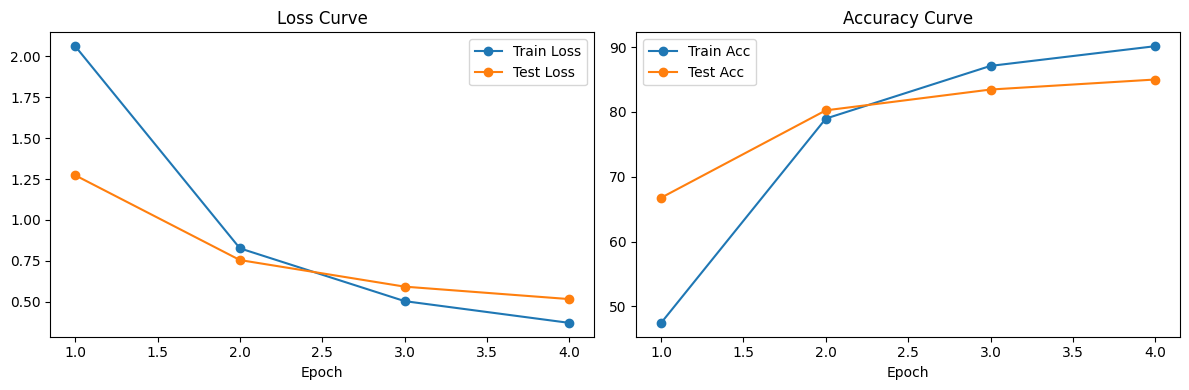

In [53]:
# 1. Loss/Accuracy grafikleri
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epoch_list, train_loss_list, label='Train Loss', marker='o')
ax1.plot(epoch_list, test_loss_list, label='Test Loss', marker='o')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epoch_list, train_acc_list, label='Train Acc', marker='o')
ax2.plot(epoch_list, test_acc_list, label='Test Acc', marker='o')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loss_accuracy_curves.png", dpi=150)
plt.show()

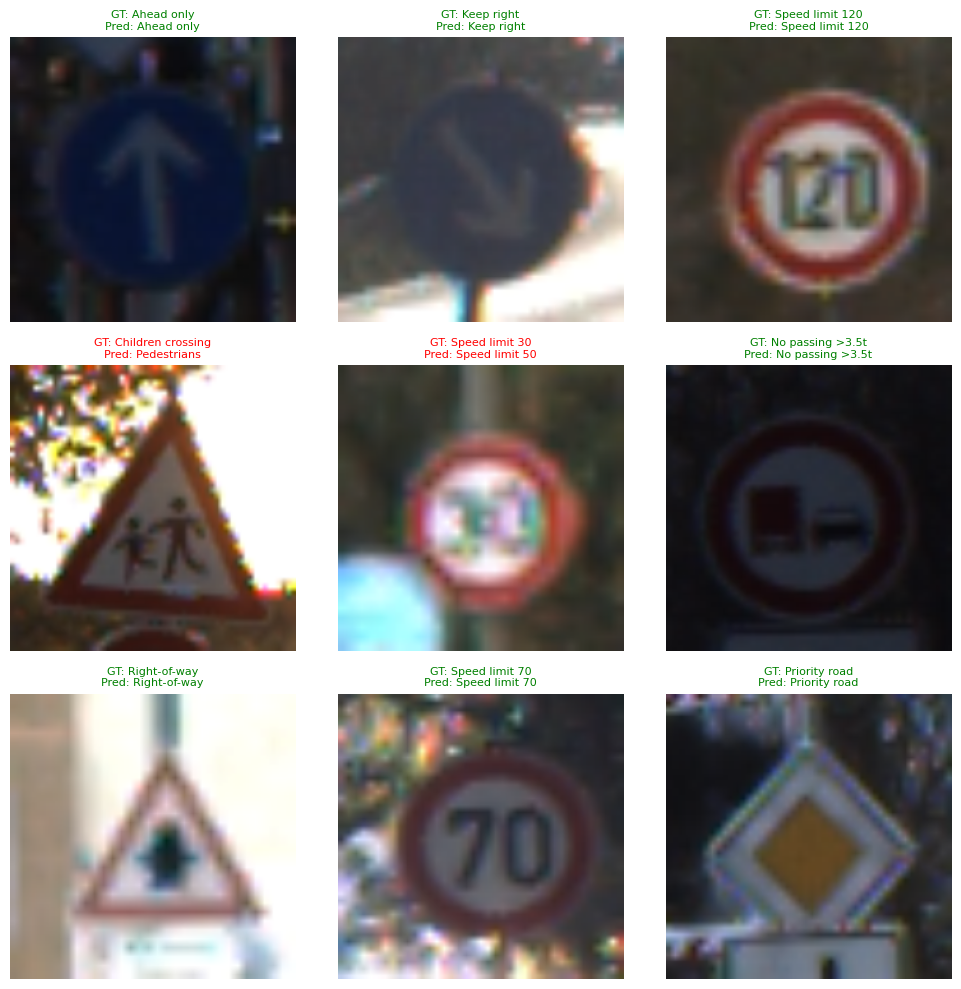

In [54]:
# 2. Tahmin görselleri
import random
model.eval()
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

with torch.inference_mode():
    for i in range(9):
        idx = random.randint(0, len(test_data)-1)
        image, label = test_data[idx]
        y_pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img  = (image * std + mean).clip(0, 1)

        axes[i].imshow(img.permute(1,2,0))
        axes[i].set_title(f"GT: {class_names[label]}\nPred: {class_names[y_pred]}",
                          color="green" if label == y_pred else "red", fontsize=8)
        axes[i].axis("off")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/predictions.png", dpi=150)
plt.show()

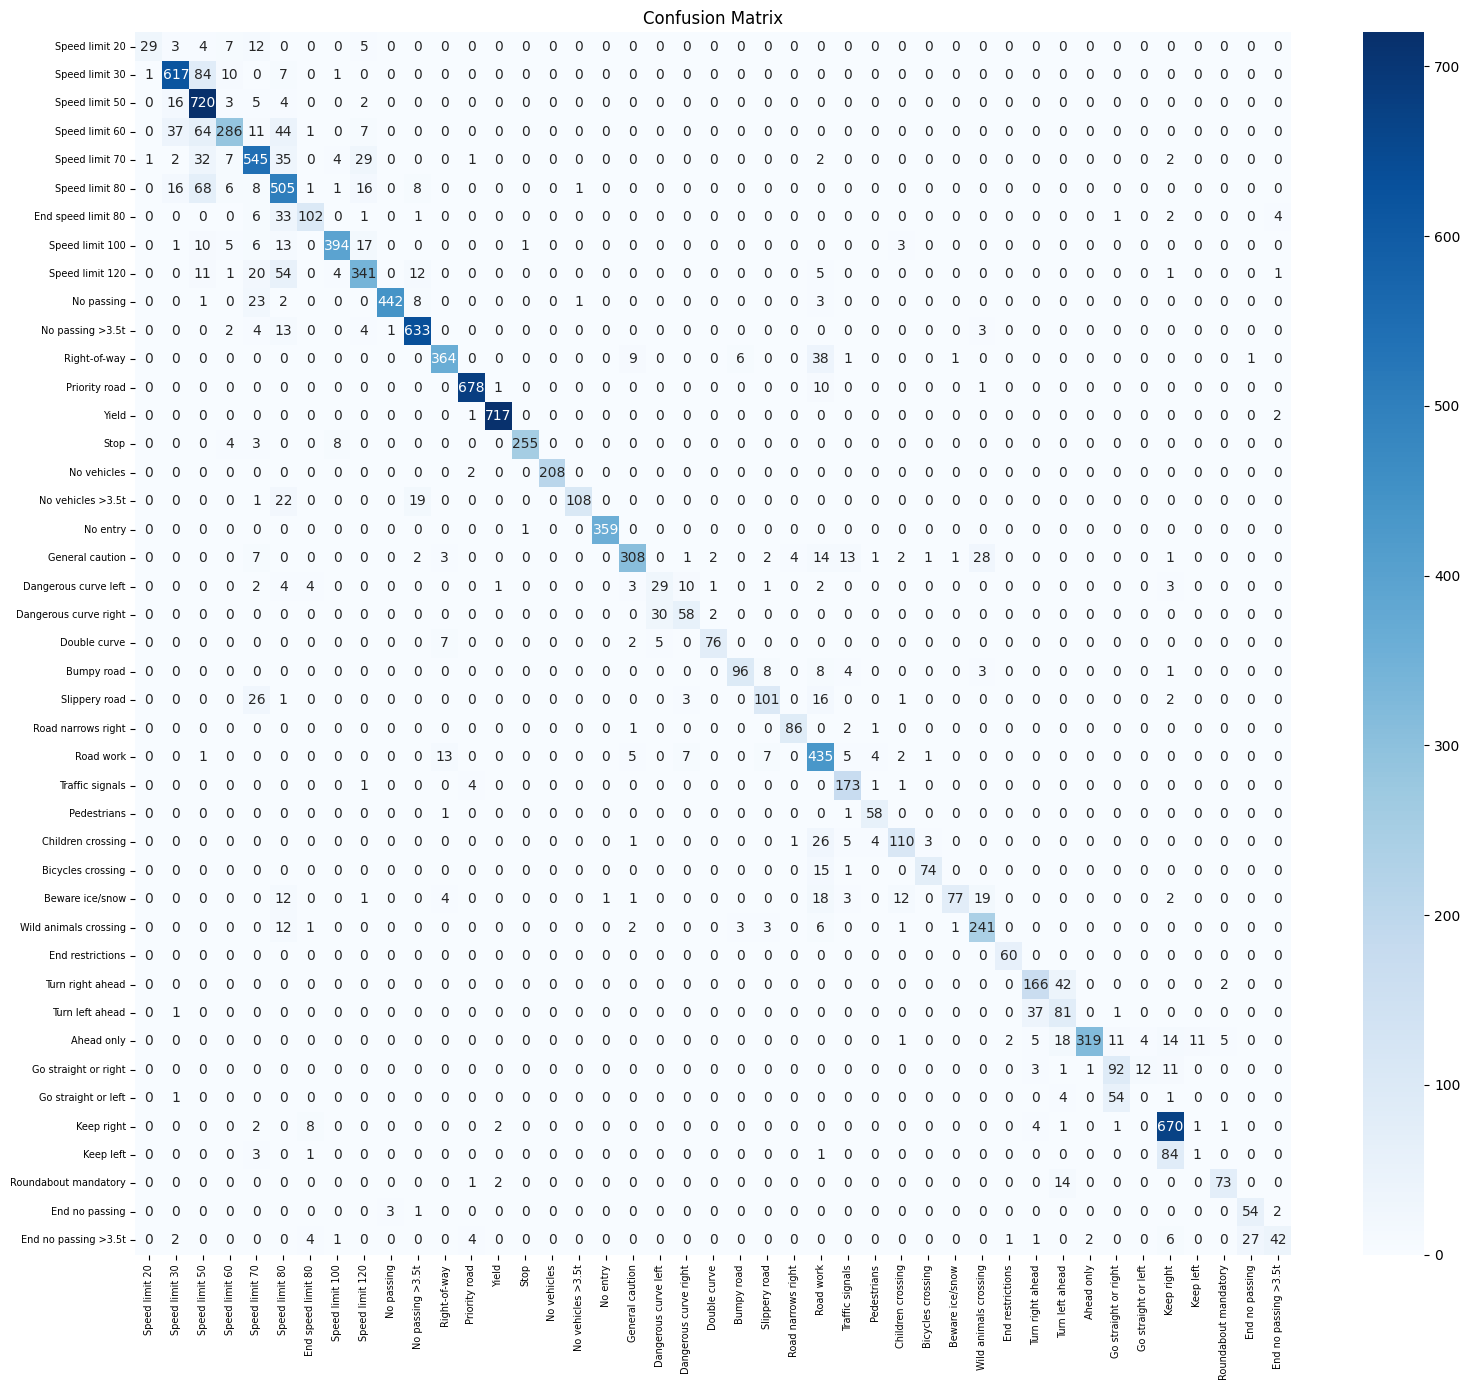

In [55]:
# 3. Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        all_preds.extend(model(X).argmax(dim=1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=150)
plt.show()